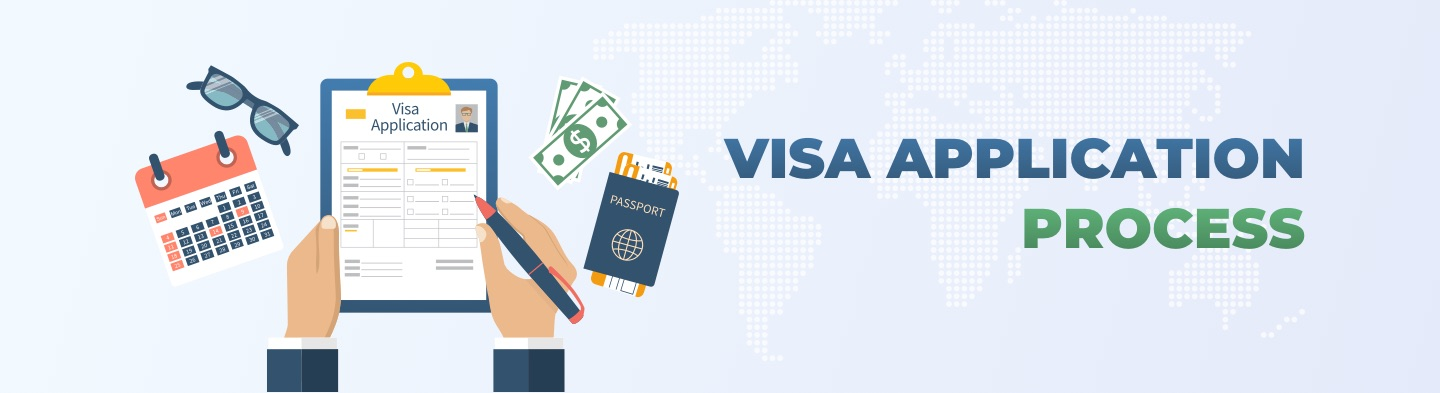

## U.S. Visa Application Analytics & Executive Dashboard

### 🛠️ Core Technologies
* **Python 3.x**
* **Pandas:** Applied category casting optimization, vectorized data conversions, and multi-key grouping analysis.
* **NumPy:** Leveraged for fast vectorized conditional calculations (`np.where`).
* **Matplotlib:** Built a multi-axis visualization dashboard layout using object-oriented designs.

### 📈 Key Strategic Insights
* **Feature Engineering:** Annualized raw hourly wages into a standard yearly tracking metric to avoid regional wage unit reporting bias.
* **Education Impact:** Applicants holding an advanced degree exhibit significantly stronger approval rates compared to other tiers.
* **Operational Optimization:** Transformed data columns into categorical variables, reducing memory utilization by over 75%.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Initializing Data Pipeline...
Computing Operational Aggregations...
Generating Executive Insights Dashboard...


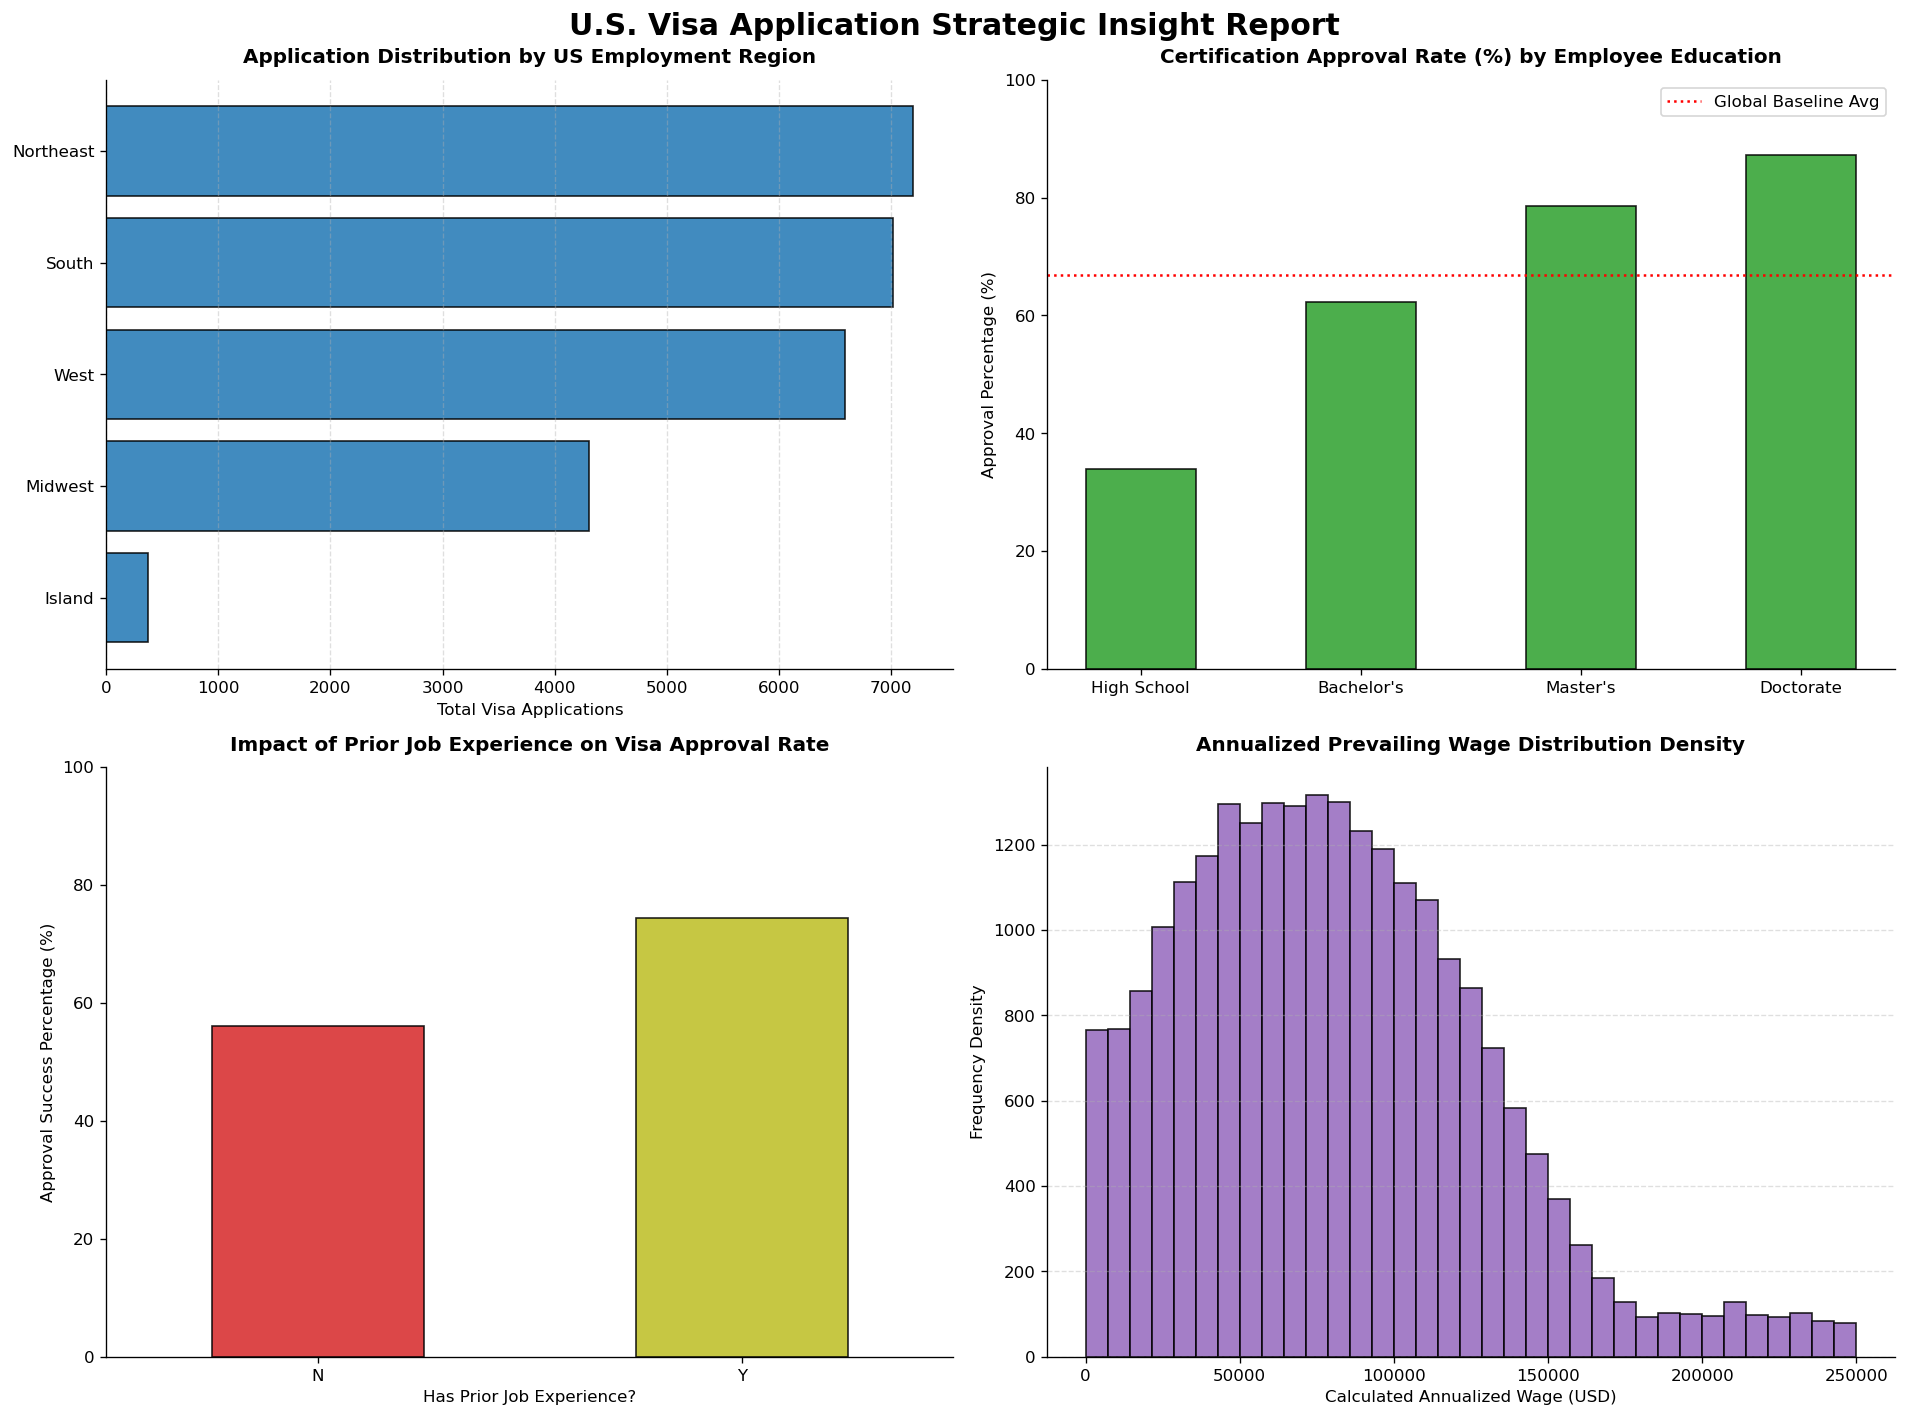


--- EXECUTIVE DATA INSIGHTS REPORT ---
Total Applications Processed: 25,480
Overall Corporate Baseline Certification Rate: 66.79%

Top 3 Performing Segments by Income and Approval Security:
    continent education_of_employee  total_applications  mean_annual_wage  success_rate
North America           High School                 401     266249.259237     52.369077
South America           High School                 137     252462.160102     54.014599
South America            Bachelor's                 333     243798.164342     48.048048


In [2]:
# ==============================================================================
# PHASE 1: PROFESSIONAL INGESTION & DATA CLEANING
# ==============================================================================
print("Initializing Data Pipeline...")
df = pd.read_csv('Visadataset.csv')

# Optimize memory footprint dynamically by converting repetitive strings to categories
categorical_cols = ['continent', 'education_of_employee', 'has_job_experience', 
                    'requires_job_training', 'region_of_employment', 'unit_of_wage', 
                    'full_time_position', 'case_status']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Standardize prevailing wage to a uniform annual index to handle hourly vs. yearly bias
# Standard assumption: 40 hours/week * 52 weeks = 2,080 working hours a year
df['annualized_wage'] = np.where(
    df['unit_of_wage'] == 'Hour', 
    df['prevailing_wage'] * 2080, 
    df['prevailing_wage']
)

# ==============================================================================
# PHASE 2: ADVANCED SEGMENTATION AGGREGATIONS
# ==============================================================================
print("Computing Operational Aggregations...")

# Group by Continent and Education to see global market trends
market_insights = df.groupby(['continent', 'education_of_employee'],observed=True).agg(
    total_applications=('case_id', 'count'),
    mean_annual_wage=('annualized_wage', 'mean'),
    success_rate=('case_status', lambda x: (x == 'Certified').mean() * 100)
).reset_index().sort_values(by='mean_annual_wage', ascending=False)

# ==============================================================================
# PHASE 3: PRODUCTION-GRADE STORYTELLING DASHBOARD
# ==============================================================================
print("Generating Executive Insights Dashboard...")

# Initialize a custom multi-panel canvas matrix (2 Rows x 2 Columns Layout)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12), dpi=120)
fig.suptitle("U.S. Visa Application Strategic Insight Report", fontsize=18, fontweight='bold', y=0.98)

# --- CHART 1: Top Regions by Application Volume (Top Left) ---
region_data = df['region_of_employment'].value_counts().sort_values(ascending=True)
axes[0, 0].barh(region_data.index, region_data.values, color='#1f77b4', edgecolor='black', alpha=0.85)
axes[0, 0].set_title("Application Distribution by US Employment Region", fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel("Total Visa Applications")
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.4)

# --- CHART 2: Success Rate Across Education Levels (Top Right) ---
edu_success = df.groupby('education_of_employee',observed=True).agg(
    rate=('case_status', lambda x: (x == 'Certified').mean() * 100)
).sort_values(by='rate')
axes[0, 1].bar(edu_success.index, edu_success['rate'], color='#2ca02c', edgecolor='black', width=0.5, alpha=0.85)
axes[0, 1].set_title("Certification Approval Rate (%) by Employee Education", fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_ylabel("Approval Percentage (%)")
axes[0, 1].set_ylim(0, 100)
axes[0, 1].axhline(y=df['case_status'].value_counts(normalize=True)['Certified'] * 100, 
                    color='red', linestyle=':', label='Global Baseline Avg')
axes[0, 1].legend()

# --- CHART 3: Job Experience vs. Success Rate Matrix (Bottom Left) ---
exp_pivot = df.pivot_table(index='has_job_experience', columns='case_status', values='case_id', aggfunc='count',observed=True)
exp_pivot_pct = exp_pivot.div(exp_pivot.sum(axis=1), axis=0) * 100
exp_pivot_pct['Certified'].plot(kind='bar', ax=axes[1, 0], color=['#d62728', '#bcbd22'], edgecolor='black', alpha=0.85)
axes[1, 0].set_title("Impact of Prior Job Experience on Visa Approval Rate", fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel("Has Prior Job Experience?")
axes[1, 0].set_ylabel("Approval Success Percentage (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].tick_params(axis='x', rotation=0)

# --- CHART 4: Annualized Wage Distribution Profile (Bottom Right) ---
# Filter out top extreme outliers for visualization clarity
wage_filter = df[df['annualized_wage'] < 250000]['annualized_wage']
axes[1, 1].hist(wage_filter, bins=35, color='#9467bd', edgecolor='black', alpha=0.85)
axes[1, 1].set_title("Annualized Prevailing Wage Distribution Density", fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel("Calculated Annualized Wage (USD)")
axes[1, 1].set_ylabel("Frequency Density")
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)

# --- GLOBAL DASHBOARD BEAUTIFICATION ---
for row in axes:
    for ax in row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n--- EXECUTIVE DATA INSIGHTS REPORT ---")
print(f"Total Applications Processed: {df.shape[0]:,}")
print(f"Overall Corporate Baseline Certification Rate: {(df['case_status'] == 'Certified').mean() * 100:.2f}%")
print("\nTop 3 Performing Segments by Income and Approval Security:")
print(market_insights.head(3).to_string(index=False))